# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

In [1]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  
print("Libraries ready!")

Libraries ready!


In [2]:
mu    = 0   
sigma = 1   

#  normal distribution object
normal = stats.norm(loc=mu, scale=sigma)

print(f"Mean = {normal.mean()}")  
print(f"Std  = {normal.std()}")    

Mean = 0.0
Std  = 1.0


In [3]:
# 1000 values generate
samples = normal.rvs(1000)


print(f"Generated samples : {len(samples)}")
print(f"Sample mean       : {samples.mean():.4f}")  
print(f"Sample std        : {samples.std():.4f}")

Generated samples : 1000
Sample mean       : 0.0193
Sample std        : 0.9787


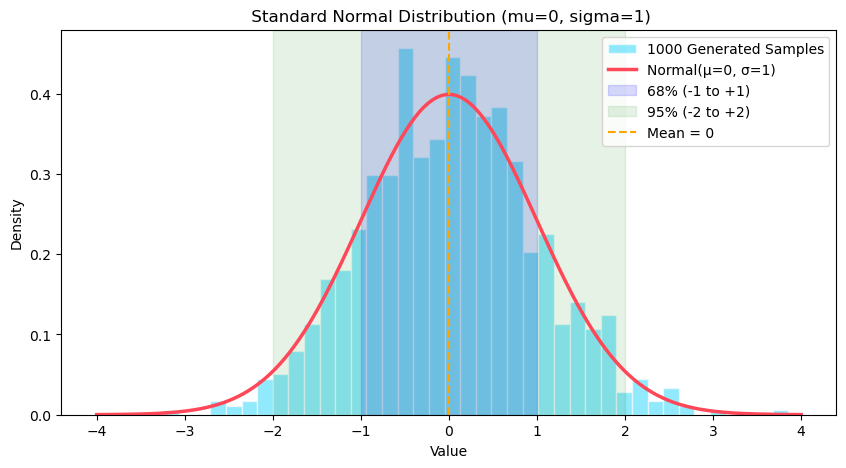

In [ ]:
plt.figure(figsize=(10, 5))

# Histogram — actual generated data
plt.hist(samples, bins=40,
         density=True,
         color='#48dbfb',
         alpha=0.6,
         edgecolor='white',
         label='1000 Generated Samples')

# Smooth curve — theoretical normal
x = np.linspace(-4, 4, 300)
plt.plot(x, normal.pdf(x),
         color='#ff4757',
         linewidth=2.5,
         label='Normal(mu=0, sigma=1)')

# 3 zones shade 
plt.axvspan(-1, 1, alpha=0.15, color='blue',  label='68% (-1 to +1)')
plt.axvspan(-2, 2, alpha=0.10, color='green', label='95% (-2 to +2)')
plt.axvline(0, color='orange', linestyle='--',
            linewidth=1.5, label='Mean = 0')

plt.title(' Standard Normal Distribution (mu=0, sigma=1)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [6]:
# how many samples -1 to +1 
within_1 = np.sum((samples >= -1) & (samples <= 1))
within_2 = np.sum((samples >= -2) & (samples <= 2))
within_3 = np.sum((samples >= -3) & (samples <= 3))

print(f"Within ±1sigma : {within_1/10:.1f}%  (theory: 68%)")
print(f"Within ±2sigma : {within_2/10:.1f}%  (theory: 95%)")
print(f"Within ±3sigma : {within_3/10:.1f}%  (theory: 99.7%)")

Within ±1sigma : 69.8%  (theory: 68%)
Within ±2sigma : 95.9%  (theory: 95%)
Within ±3sigma : 99.7%  (theory: 99.7%)


In [7]:
# Q2 — "Simulate exam scores of 1000 students. What percentage scored above 85?"

mu_exam    = 70   # average score 70
sigma_exam = 10 

In [8]:
exam_dist   = stats.norm(loc=mu_exam, scale=sigma_exam)
exam_scores = exam_dist.rvs(1000)

print(exam_scores[:10])

[83.99355437 79.24633683 70.5963037  63.53063222 76.98223314 73.93485385
 78.9519322  76.35171802 80.49552715 64.64764788]


In [10]:
# By Simulation  count
upar_85       = np.sum(exam_scores > 85)
percentage    = upar_85 / 1000 * 100
print(f"By Simulation  : {percentage:.1f}%")

# By Theory calculate
theory = (1 - exam_dist.cdf(85)) * 100

print(f"By Theory      : {theory:.1f}%")


By Simulation  : 8.0%
By Theory      : 6.7%


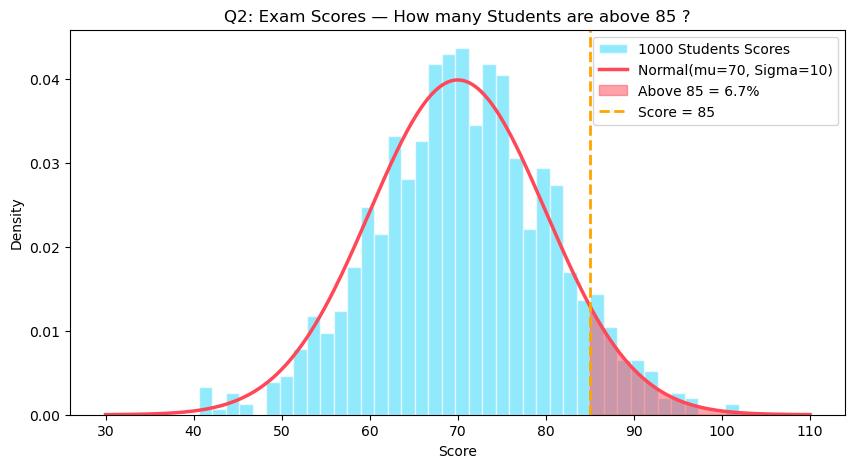

In [11]:
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(exam_scores, bins=40,
         density=True,
         color='#48dbfb', alpha=0.6,
         edgecolor='white',
         label='1000 Students Scores')

# Bell curve
x = np.linspace(30, 110, 300)
plt.plot(x, exam_dist.pdf(x),
         color='#ff4757', linewidth=2.5,
         label=f'Normal(mu={mu_exam}, Sigma={sigma_exam})')

# score more then 85 is  RED
x_above = np.linspace(85, 110, 200)
plt.fill_between(x_above,
                 exam_dist.pdf(x_above),
                 alpha=0.5,
                 color='#ff4757',
                 label=f'Above 85 = {theory:.1f}%')

# 85 se UPAR ek vertical line
plt.axvline(85, color='orange',
            linestyle='--', linewidth=2,
            label='Score = 85')

plt.title('Q2: Exam Scores — How many Students are above 85 ?')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [13]:
# Q3 — "How does changing standard deviation affect the spread? Visualize.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

x = np.linspace(-60, 60, 500)


sigmas = [2, 5, 10, 20]


colors = ['#ff4757', '#48dbfb', '#1dd1a1', '#feca57']



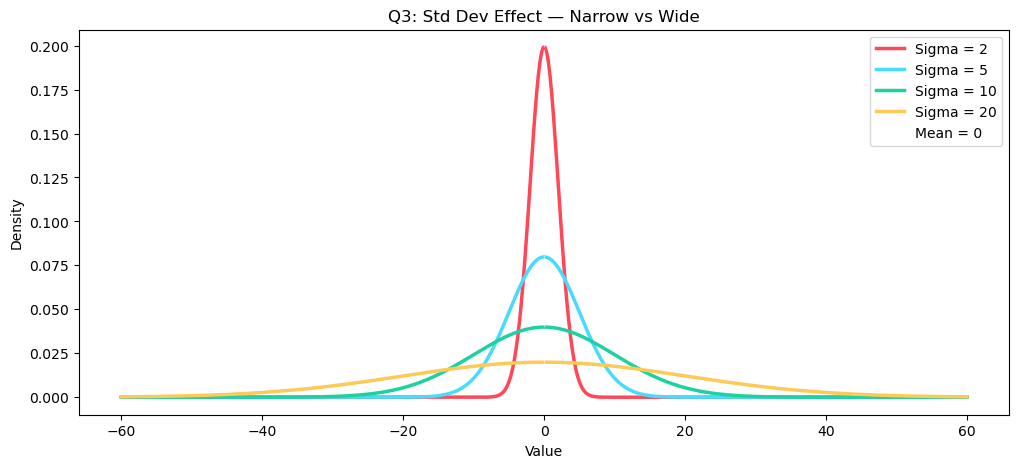

In [14]:
plt.figure(figsize=(12, 5))

for sigma, color in zip(sigmas, colors):
    dist = stats.norm(loc=0, scale=sigma)
    plt.plot(x, dist.pdf(x),
             color=color,
             linewidth=2.5,
             label=f'Sigma = {sigma}')

plt.axvline(0, color='white',
            linestyle='--',
            linewidth=1,
            alpha=0.5,
            label='Mean = 0')

plt.title('Q3: Std Dev Effect — Narrow vs Wide')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

In [15]:
# Your code here
# Q4 — "Simulate 100 coin toss experiments with p=0.5. Plot distribution.
n = 100   
p = 0.5

In [16]:
from scipy import stats

binom = stats.binom(n, p)

print(f"Mean     = {binom.mean()}")   
print(f"Std Dev  = {binom.std():.2f}") 

Mean     = 50.0
Std Dev  = 5.00


In [17]:
# 1000 time 100 coin toss 
simulations = binom.rvs(1000)

print(f"Min heads : {simulations.min()}")  
print(f"Max heads : {simulations.max()}")  
print(f"Avg heads : {simulations.mean():.1f}")  

Min heads : 36
Max heads : 67
Avg heads : 50.0


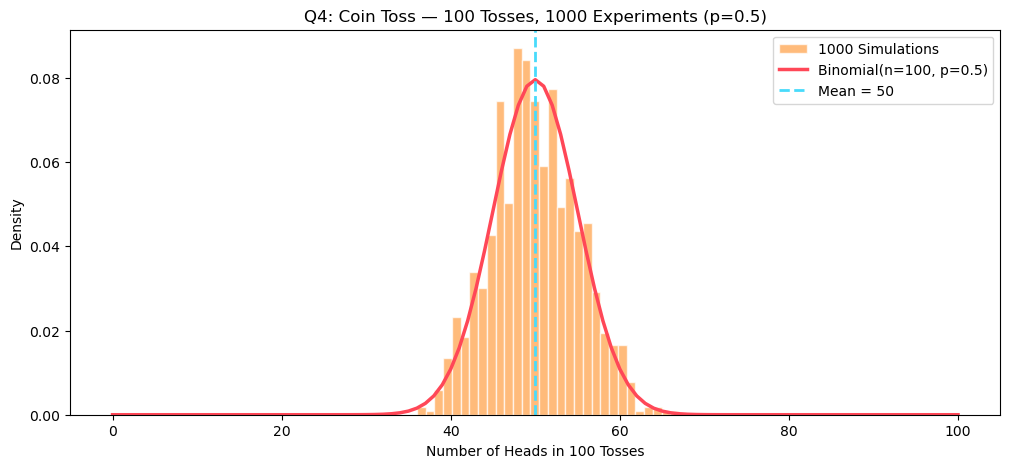

In [19]:

plt.figure(figsize=(12, 5))

# Simulation — histogram
plt.hist(simulations, bins=30,
         density=True,
         color='#ff9f43', alpha=0.7,
         edgecolor='white',
         label='1000 Simulations')

# Theory — smooth curve
k = np.arange(0, n+1)
plt.plot(k, binom.pmf(k),
         color='#ff4757',
         linewidth=2.5,
         label=f'Binomial(n={n}, p={p})')

# Mean line
plt.axvline(binom.mean(),
            color='#48dbfb',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {binom.mean():.0f}')

plt.title(f'Q4: Coin Toss — 100 Tosses, 1000 Experiments (p={p})')
plt.xlabel('Number of Heads in 100 Tosses')
plt.ylabel('Density')
plt.legend()
plt.show()

In [20]:
# Q5 — "Student guesses MCQs (4 options). Probability of exactly 6 correct out of 10?
n = 10    # 10 questions
p = 0.25  # 1/4 = 0.25 
k = 6 



P(exactly 6 sahi) = 0.0162 = 1.62%
P(6 ya zyada sahi) = 0.0197 = 1.97%
P(6 se kam sahi)   = 0.9803 = 98.03%

Mean  = nxp = 2.5 questions expected sahi


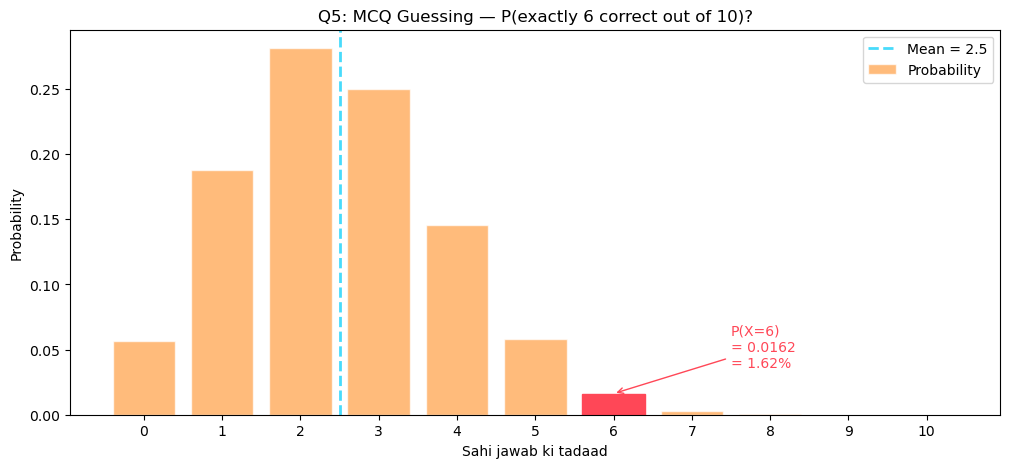

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

#Parameters 
n = 10  
p = 0.25 
k = 6     

# Binomial object 
binom = stats.binom(n, p)

# Probabilities 
p_exactly_6 = binom.pmf(6)
p_atleast_6 = 1 - binom.cdf(5)
p_less_6    = binom.cdf(5)

print(f"P(exactly 6 sahi) = {p_exactly_6:.4f} = {p_exactly_6*100:.2f}%")
print(f"P(6 ya zyada sahi) = {p_atleast_6:.4f} = {p_atleast_6*100:.2f}%")
print(f"P(6 se kam sahi)   = {p_less_6:.4f} = {p_less_6*100:.2f}%")
print(f"\nMean  = nxp = {binom.mean():.1f} questions expected sahi")

# Plot
plt.figure(figsize=(12, 5))

k_values = np.arange(0, n+1)
probs    = binom.pmf(k_values)

bars = plt.bar(k_values, probs,
               color='#ff9f43',
               alpha=0.7,
               edgecolor='white',
               label='Probability')

# Exactly 6 
bars[6].set_color('#ff4757')
bars[6].set_alpha(1.0)

# Annotation
plt.annotate(f'P(X=6)\n= {p_exactly_6:.4f}\n= {p_exactly_6*100:.2f}%',
             xy=(6, p_exactly_6),
             xytext=(7.5, p_exactly_6+0.02),
             fontsize=10,
             color='#ff4757',
             arrowprops=dict(arrowstyle='->',
                           color='#ff4757'))

plt.axvline(binom.mean(),
            color='#48dbfb',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {binom.mean():.1f}')

plt.title('Q5: MCQ Guessing — P(exactly 6 correct out of 10)?')
plt.xlabel('Sahi jawab ki tadaad')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.legend()
plt.show()

In [22]:
# Q6 — "When does Binomial start resembling Normal distribution? Demonstrate.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

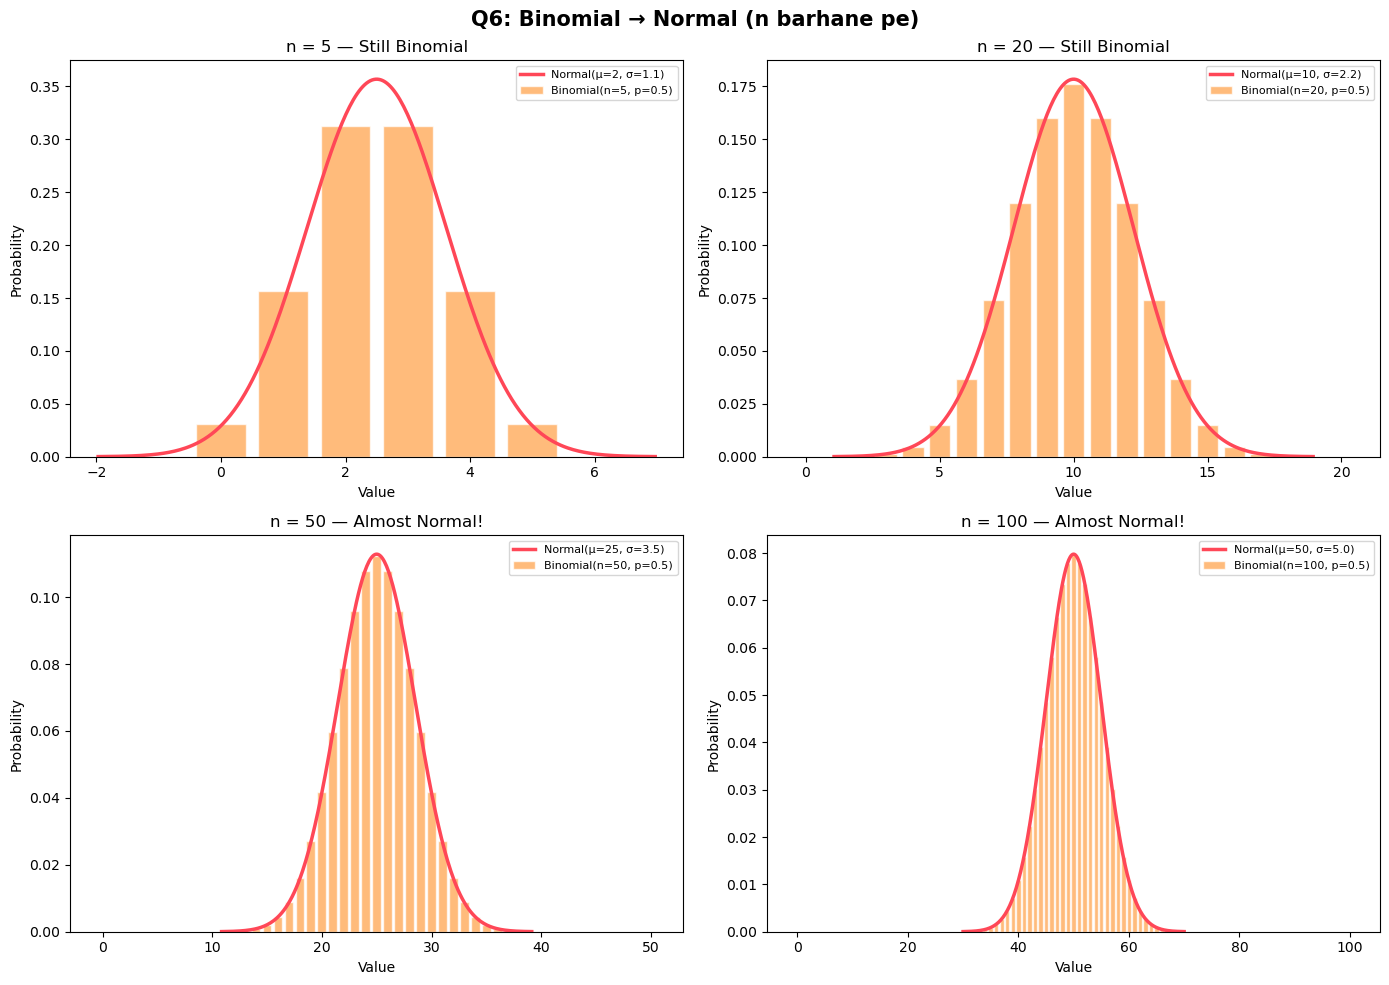

In [23]:

# for different n values 
n_values = [5, 20, 50, 100]
p        = 0.5
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for i, n in enumerate(n_values):

    # Binomial
    binom  = stats.binom(n, p)
    k_vals = np.arange(0, n+1)
    probs  = binom.pmf(k_vals)

    # Normal — same mean and std
    mu_n   = n * p
    sig_n  = np.sqrt(n * p * (1-p))
    normal = stats.norm(mu_n, sig_n)

    ax = axes[i]

    # Binomial bars
    ax.bar(k_vals, probs,
           color='#ff9f43', alpha=0.7,
           edgecolor='white',
           label=f'Binomial(n={n}, p={p})')

    # Normal curve
    x = np.linspace(mu_n - 4*sig_n,
                    mu_n + 4*sig_n, 300)
    ax.plot(x, normal.pdf(x),
            color='#ff4757',
            linewidth=2.5,
            label=f'Normal(μ={mu_n:.0f}, σ={sig_n:.1f})')

    ax.set_title(f'n = {n} — {"Almost Normal!" if n>=30 else "Still Binomial"}',
                 fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)

plt.suptitle('Q6: Binomial → Normal (n barhane pe)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



In [24]:
# ─── Print results ────────────────────────────────────
print("Result on different N values:")
print(f"n=5   → Binomial and Normal have large different ")
print(f"n=20  → less different ")
print(f"n=50  → similar")
print(f"n=100 → Same as Normal  ✅")
print(f"\nRule: n >= 30 then Binomial ≈ Normal!")

Result on different N values:
n=5   → Binomial and Normal have large different 
n=20  → less different 
n=50  → similar
n=100 → Same as Normal  ✅

Rule: n >= 30 then Binomial ≈ Normal!


## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

In [1]:
# Your code here
#Q7 — "Model number of calls received per minute in a call center (lambda=5)"
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

lam = 5   # average 5 calls per minute

#  Poisson object
poisson = stats.poisson(lam)

print(f"Lambda (λ)   = {lam}")
print(f"Mean         = {poisson.mean()}")   
print(f"Variance     = {poisson.var()}")    
print(f"Std Dev      = {poisson.std():.2f}") 


Lambda (λ)   = 5
Mean         = 5.0
Variance     = 5.0
Std Dev      = 2.24


In [2]:
# Probabilities 
print(f"\nP(exactly 5 calls) = {poisson.pmf(5):.4f}")
print(f"P(0 calls)         = {poisson.pmf(0):.4f}")
print(f"P(10+ calls)       = {1-poisson.cdf(9):.4f}")


P(exactly 5 calls) = 0.1755
P(0 calls)         = 0.0067
P(10+ calls)       = 0.0318


In [3]:
#1000 minutes simulate 
simulations = poisson.rvs(1000)
print(f"\nSimulated avg calls = {simulations.mean():.2f}")


Simulated avg calls = 4.99


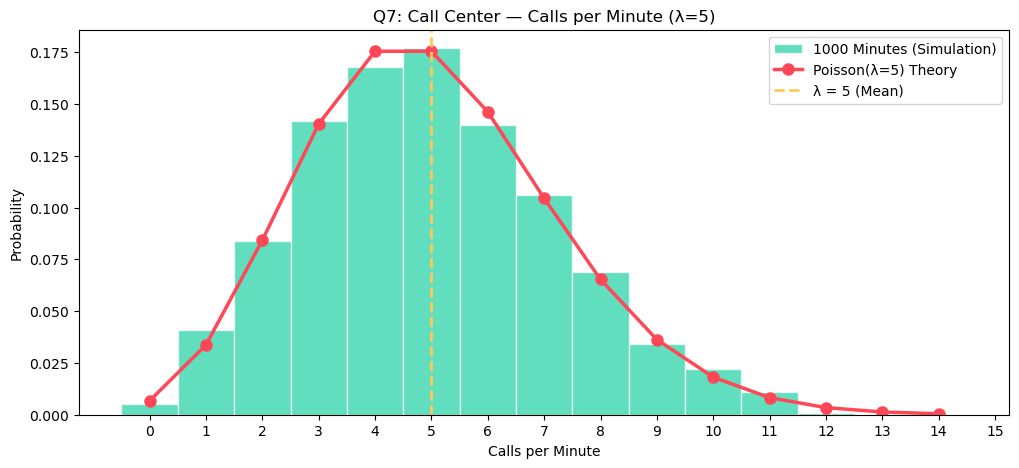

In [4]:
plt.figure(figsize=(12, 5))

# Simulation — histogram
plt.hist(simulations, bins=range(0, 16),
         density=True,
         color='#1dd1a1', alpha=0.7,
         edgecolor='white',
         label='1000 Minutes (Simulation)',
         align='left')
# Theory — PMF dots
k_vals = np.arange(0, 15)
plt.plot(k_vals, poisson.pmf(k_vals),
         'o-', color='#ff4757',
         linewidth=2.5, markersize=8,
         label=f'Poisson(λ={lam}) Theory')

# Lambda line
plt.axvline(lam,
            color='#feca57',
            linestyle='--',
            linewidth=2,
            label=f'λ = {lam} (Mean)')
plt.title(f'Q7: Call Center — Calls per Minute (λ={lam})')
plt.xlabel('Calls per Minute')
plt.ylabel('Probability')
plt.xticks(range(0, 16))
plt.legend()
plt.show()

In [5]:
# Q8 — "What is probability of receiving exactly 3 calls in a minute?"#
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

lam = 5  
poisson = stats.poisson(lam)

In [6]:
# Calculate Exactly 3 calls probability
p_exactly_3 = poisson.pmf(3)
p_less_3    = poisson.cdf(2)
p_atleast_3 = 1 - poisson.cdf(2)

print(f"P(exactly 3 calls) = {p_exactly_3:.4f} = {p_exactly_3*100:.2f}%")
print(f"P(less than 3)     = {p_less_3:.4f} = {p_less_3*100:.2f}%")
print(f"P(3 ya zyada)      = {p_atleast_3:.4f} = {p_atleast_3*100:.2f}%")

P(exactly 3 calls) = 0.1404 = 14.04%
P(less than 3)     = 0.1247 = 12.47%
P(3 ya zyada)      = 0.8753 = 87.53%


In [8]:
# compare all probabilities 
print(f"\nALL 10  probabilities:")
for k in range(11):
    bar = '█' * int(poisson.pmf(k) * 100)
    print(f"P(X={k:2d}) = {poisson.pmf(k):.4f}  {bar}")


ALL 10  probabilities:
P(X= 0) = 0.0067  
P(X= 1) = 0.0337  ███
P(X= 2) = 0.0842  ████████
P(X= 3) = 0.1404  ██████████████
P(X= 4) = 0.1755  █████████████████
P(X= 5) = 0.1755  █████████████████
P(X= 6) = 0.1462  ██████████████
P(X= 7) = 0.1044  ██████████
P(X= 8) = 0.0653  ██████
P(X= 9) = 0.0363  ███
P(X=10) = 0.0181  █


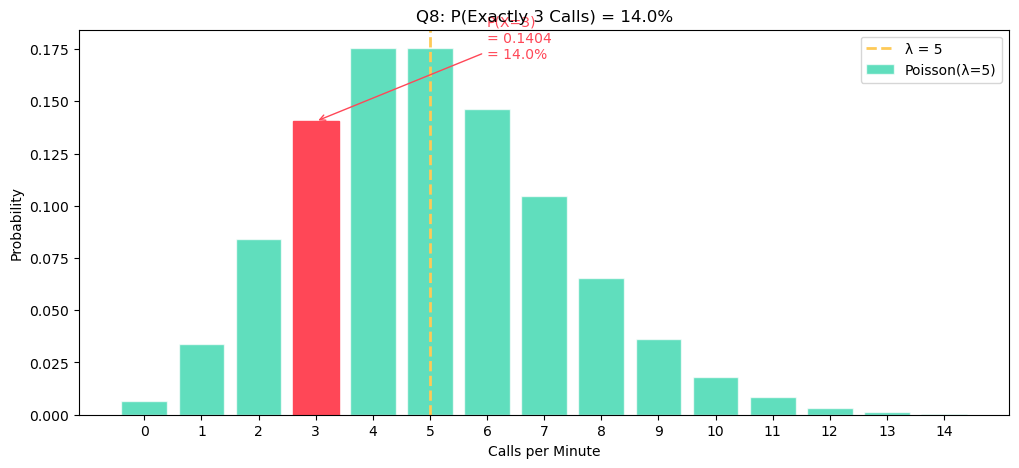

In [ ]:
plt.figure(figsize=(12, 5))

k_vals = np.arange(0, 15)
probs  = poisson.pmf(k_vals)

# All bars
bars = plt.bar(k_vals, probs,
               color='#1dd1a1',
               alpha=0.7,
               edgecolor='white',
               label='Poisson(λ=5)')

# Exactly 3 highlight 
bars[3].set_color('#ff4757')
bars[3].set_alpha(1.0)

# Annotation
plt.annotate(
    f'P(X=3)\n= {p_exactly_3:.4f}\n= {p_exactly_3*100:.1f}%',
    xy=(3, p_exactly_3),
    xytext=(6, p_exactly_3 + 0.03),
    fontsize=10,
    color='#ff4757',
    arrowprops=dict(arrowstyle='->',
                    color='#ff4757'))

# Lambda line
plt.axvline(lam,
            color='#feca57',
            linestyle='--',
            linewidth=2,
            label=f'λ = {lam}')

plt.title(f'Q8: P(Exactly 3 Calls) = {p_exactly_3*100:.1f}%')
plt.xlabel('Calls per Minute')
plt.ylabel('Probability')
plt.xticks(k_vals)
plt.legend()
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

In [ ]:
# Your code here


## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


In [ ]:
# Your code here


## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [ ]:
# Your code here


## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


In [ ]:
# Your code here


## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


In [ ]:
# Your code here
